# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [ ]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

### Cargar Dataset

In [ ]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [ ]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
-

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna ... .


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [ ]:
# Corregir el tipo de dato
df['edad'] = df['edad'].astype(int)
df['satisfaccion'] = df['satisfaccion'].astype(float)  # se deja float por ser escala continua

In [ ]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [ ]:
# Estadísticas descriptivas de variables numéricas
df.describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000


Diagnóstico inicial de variables numéricas

edad — Rango de 18 a 75 años, media de 38. Distribución razonable sin valores imposibles.

nivel_ingreso — Va de 8,000 a 74,790, con media de 30,019. Rango amplio pero plausible.

visitas_mes — Entre 1 y 25 visitas, media de 10. Sin valores extremos sospechosos.

compras_mes — Entre 0 y 8, media de 1.2. La mayoría de usuarios compra poco o nada en el mes.

gasto_publicidad_dirigida — Va de 0 a 75.5, media de 20.1. Hay usuarios sin gasto asignado (mínimo 0).

satisfaccion — Escala del 1 al 5, media de 3.6. Distribución centrada, sin valores fuera de rango.

miembro_premium — Media de 0.14, lo que indica que solo el ~14% de usuarios son premium.

abandono — Media de 0.15, indicando que aproximadamente el 15% de clientes ha abandonado la plataforma.

ingreso_anual — Va de 0 a 244.69, con media de 36.59 y alta desviación estándar (34.5). Hay clientes que no generan ingreso y otros con valores muy altos. Posibles outliers a considerar.

#### Explorar variables binarias

In [ ]:
# Verificar que cada columna tenga únicamente dos valores posibles
print(df['miembro_premium'].value_counts())
print()
print(df['abandono'].value_counts())

0    12911
1     2089
Name: miembro_premium, dtype: int64

0    12739
1     2261
Name: abandono, dtype: int64


Diagnóstico inicial de variables binarias

**miembro_premium — Solo contiene valores 0 y 1. El 86% de clientes no es premium (12,911) y solo el 14% sí lo es (2,089). No requiere transformación.**

**abandono — Solo contiene valores 0 y 1. El 85% de clientes permanece activo (12,739) y el 15% ha abandonado la plataforma (2,261). No requiere transformación.**

#### Explorar variables categóricas

In [ ]:
# Verificar el número de valores únicos por variable categórica
print(df[['id_cliente', 'tipo_dispositivo', 'region']].nunique())

id_cliente          15000
tipo_dispositivo        3
region                  4
dtype: int64


In [ ]:
# Explorar variables categóricas y cómo se distribuyen
print(df['tipo_dispositivo'].value_counts())
print()
print(df['region'].value_counts())

móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64

norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64


Diagnóstico inicial de variables categóricas

**tipo_dispositivo — Tiene 3 categorías: móvil (65.5%), escritorio (24.8%) y tablet (9.7%). La mayoría de usuarios accede desde móvil. Sin valores inesperados.**

**region — Tiene 4 categorías: norte (29.3%), oeste (25.4%), sur (24.8%) y este (20.5%). Distribución relativamente balanceada entre regiones. Sin valores inesperados.**

**id_cliente — 15,000 valores únicos, confirma que cada fila representa un cliente distinto. No se usará en el análisis correlacional.**

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

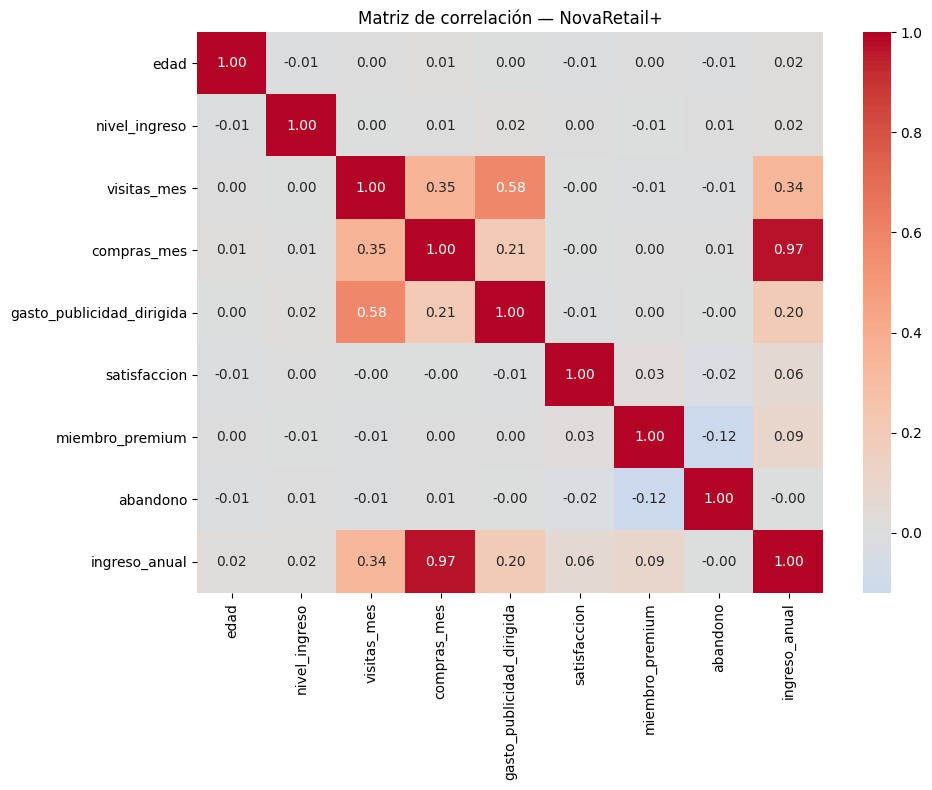

In [ ]:
# Visualizar la matriz de correlación para identificar relaciones
columnas_numericas = ['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes',
                      'gasto_publicidad_dirigida', 'satisfaccion',
                      'miembro_premium', 'abandono', 'ingreso_anual']

matriz_corr = df[columnas_numericas].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlación — NovaRetail+')
plt.tight_layout()
plt.show()

Observaciones generales `(Heatmap)`

**Se observa una correlación muy fuerte entre compras_mes y visitas_mes (0.35), y entre visitas_mes y gasto_publicidad_dirigida (0.58). Esto sugiere posible colinealidad entre variables de comportamiento.
La mayoría de variables tienen correlaciones cercanas a 0 con edad, nivel_ingreso y satisfaccion, indicando poca relación lineal con esas variables.
miembro_premium y abandono muestran una correlación negativa débil (-0.12), lo que es esperable.**


Observaciones respecto a `ingreso_anual`  

**Presenta una correlación muy fuerte con compras_mes (0.97) — es la relación más relevante del dataset.
Correlación moderada con visitas_mes (0.34) y débil con gasto_publicidad_dirigida (0.20).
Las demás variables (edad, nivel_ingreso, satisfaccion, abandono) tienen correlación prácticamente nula con ingreso_anual.**

### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.
  
Se incluye porque permite visualizar simultáneamente las relaciones entre las 4 variables más relevantes. Se confirma visualmente la fuerte relación entre compras_mes e ingreso_anual, y la relación moderada entre visitas_mes y gasto_publicidad_dirigida.

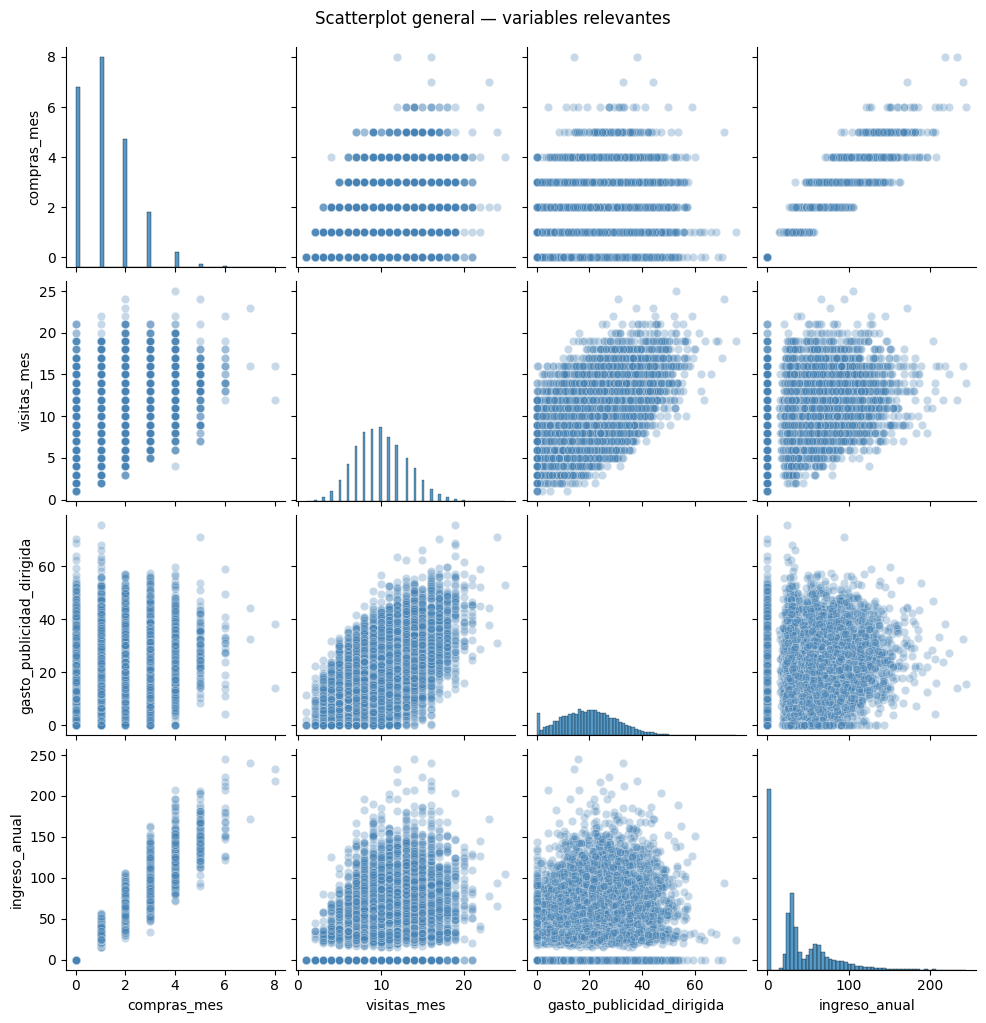

In [ ]:
# Scatterplot general — pairplot de variables relevantes
cols_relevantes = ['compras_mes', 'visitas_mes', 'gasto_publicidad_dirigida', 'ingreso_anual']
sns.pairplot(df[cols_relevantes], plot_kws={'alpha': 0.3, 'color': 'steelblue'})
plt.suptitle('Scatterplot general — variables relevantes', y=1.02)
plt.show()

### Scatterplot para pares clave

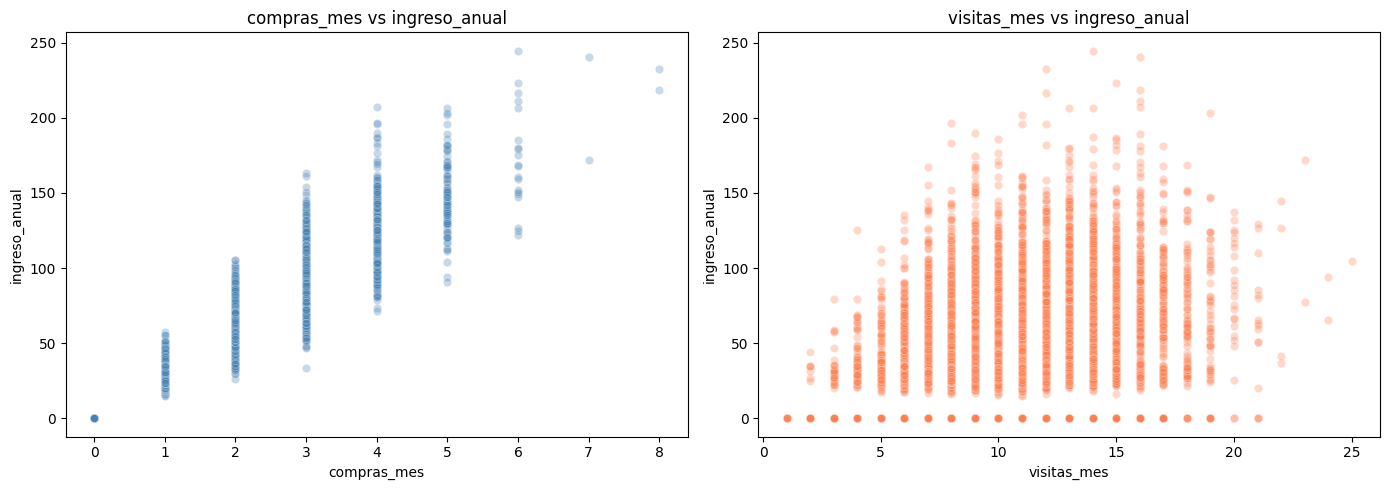

In [ ]:
# Scatterplot para pares clave
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x='compras_mes', y='ingreso_anual', alpha=0.3, ax=axes[0], color='steelblue')
axes[0].set_title('compras_mes vs ingreso_anual')

sns.scatterplot(data=df, x='visitas_mes', y='ingreso_anual', alpha=0.3, ax=axes[1], color='coral')
axes[1].set_title('visitas_mes vs ingreso_anual')

plt.tight_layout()
plt.show()

Observaciones iniciales (Scatterplot)

compras_mes vs ingreso_anual
- Dirección: positiva muy fuerte — a mayor número de compras, mayor ingreso anual.
- Dispersión baja, los puntos forman bandas verticales bien definidas por cada valor entero de compras.

visitas_mes vs ingreso_anual
- Dirección: positiva moderada — más visitas se asocian con mayor ingreso, pero con mucha dispersión.
- Dispersión alta, la relación es menos predecible que con compras_mes.

visitas_mes vs gasto_publicidad_dirigida
- Dirección: positiva moderada — usuarios con más visitas tienden a tener mayor gasto publicitario asignado.
- Posible colinealidad con compras_mes a considerar en análisis posteriores.

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [ ]:
# Calcular correlación Pearson entre variables relevantes vs ingreso_anual
cols = ['compras_mes', 'visitas_mes', 'gasto_publicidad_dirigida',
        'nivel_ingreso', 'edad', 'satisfaccion']

print("=== Pearson ===")
for col in cols:
    r, p = stats.pearsonr(df[col], df['ingreso_anual'])
    print(f"{col}: r = {r:.4f}, p = {p:.4f}")

=== Pearson ===
compras_mes: r = 0.9671, p = 0.0000
visitas_mes: r = 0.3371, p = 0.0000
gasto_publicidad_dirigida: r = 0.1975, p = 0.0000
nivel_ingreso: r = 0.0174, p = 0.0326
edad: r = 0.0175, p = 0.0321
satisfaccion: r = 0.0562, p = 0.0000


In [ ]:
# Calcular correlación Spearman entre variables relevantes vs ingreso_anual
print("=== Spearman ===")
for col in cols:
    r, p = stats.spearmanr(df[col], df['ingreso_anual'])
    print(f"{col}: r = {r:.4f}, p = {p:.4f}")

=== Spearman ===
compras_mes: r = 0.9675, p = 0.0000
visitas_mes: r = 0.3210, p = 0.0000
gasto_publicidad_dirigida: r = 0.1850, p = 0.0000
nivel_ingreso: r = 0.0250, p = 0.0022
edad: r = 0.0161, p = 0.0487
satisfaccion: r = 0.0608, p = 0.0000


**Observaciones de correlación**

**compras_mes vs ingreso_anual**

Correlación muy fuerte tanto en Pearson (0.97) como en Spearman (0.97). Es la variable más predictiva del ingreso anual. Altamente significativa (p = 0.0000).

**visitas_mes vs ingreso_anual**

Correlación moderada en Pearson (0.34) y Spearman (0.32). Relación positiva pero con mucha dispersión. Significativa (p = 0.0000).

**gasto_publicidad_dirigida vs ingreso_anual**

Correlación débil en Pearson (0.20) y Spearman (0.19). Existe una relación positiva pero pequeña. Significativa estadísticamente (p = 0.0000).

**nivel_ingreso y edad vs ingreso_anual**

Correlaciones prácticamente nulas (0.017 y 0.018). Aunque estadísticamente significativas por el tamaño de muestra, no tienen relevancia práctica para el negocio.

**satisfaccion vs ingreso_anual**

Correlación muy débil (0.056 Pearson, 0.061 Spearman). Sin relevancia práctica pese a ser significativa estadísticamente.

### Punto-biserial

In [ ]:
# Calcular correlación entre variables relevantes
print("=== Punto Biserial ===")

binarias = ['miembro_premium', 'abandono']

for col in binarias:
    r, p = stats.pointbiserialr(df[col], df['ingreso_anual'])
    print(f"{col} vs ingreso_anual: r = {r:.4f}, p = {p:.4f}")

=== Punto Biserial ===
miembro_premium vs ingreso_anual: r = 0.0931, p = 0.0000
abandono vs ingreso_anual: r = -0.0028, p = 0.7295


**Observaciones Punto-biserial**

**miembro_premium vs ingreso_anual**

Relación positiva débil (r = 0.09). Los usuarios premium tienden a generar ligeramente más ingreso anual. Estadísticamente significativa (p = 0.0000), aunque de magnitud pequeña.

**abandono vs ingreso_anual**

Relación prácticamente nula (r = -0.003) y no significativa (p = 0.73). Si un cliente abandonó la plataforma no tiene relación observable con el ingreso que generó. No es una variable relevante para predecir ingreso.

### V de Cramér

In [ ]:
# Función para calcular V de Cramér
def cramer_v(x, y):
    tabla = pd.crosstab(x, y)
    chi2, p, dof, _ = stats.chi2_contingency(tabla)
    n = tabla.sum().sum()
    v = np.sqrt(chi2 / (n * (min(tabla.shape) - 1)))
    return v, p

In [ ]:
# Aplicar V de Cramér en variables relevantes
categoricas = ['tipo_dispositivo', 'region']

print("=== V de Cramér ===")
for col in categoricas:
    v, p = cramer_v(df[col], df['tipo_dispositivo'] if col != 'tipo_dispositivo' else df['region'])
    print(f"{col} vs {'region' if col == 'tipo_dispositivo' else 'tipo_dispositivo'}: V = {v:.4f}, p = {p:.4f}")

=== V de Cramér ===
tipo_dispositivo vs region: V = 0.0124, p = 0.5965
region vs tipo_dispositivo: V = 0.0124, p = 0.5965


**Observaciones V de Cramér**

tipo_dispositivo vs region: Asociación prácticamente nula (V = 0.012) y no significativa (p = 0.60). El tipo de dispositivo que usa un cliente no está asociado con su región geográfica. Ambas variables son independientes entre sí y ninguna muestra asociación relevante con el comportamiento de ingreso.


## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---

### Hallazgo 1 — compras_mes es el principal driver del ingreso anual

**Evidencia visual: El scatterplot de compras_mes vs ingreso_anual muestra una relación positiva muy clara, con bandas verticales bien definidas por cada valor entero de compras.**

**Evidencia numérica: Pearson r = 0.97, Spearman r = 0.97, ambos con p = 0.0000.**

**Interpretación
El número de compras mensuales está fuertemente asociado con el ingreso anual generado por el cliente. Es la variable con mayor poder explicativo del dataset.**

**No podemos afirmar
Que aumentar las compras causa mayor ingreso anual. Podría haber variables no medidas (tipo de producto, valor del ticket, descuentos) que expliquen parte de esta relación.**

**Implicación de negocio
Estrategias que incentiven la frecuencia de compra (programas de fidelidad, ofertas recurrentes, recordatorios) podrían estar fuertemente asociadas con mayor ingreso para NovaRetail+.**

### Hallazgo 2 — visitas_mes tiene una relación moderada con el ingreso anual

**Evidencia visual: El scatterplot de visitas_mes vs ingreso_anual muestra una tendencia positiva con alta dispersión.**

**Evidencia numérica: Pearson r = 0.34, Spearman r = 0.32, ambos con p = 0.0000.**

**Interpretación
Los clientes que visitan más la plataforma tienden a generar más ingreso, aunque la relación es moderada y con mucha variabilidad entre usuarios.**

**No podemos afirmar
Que incrementar las visitas causará mayor ingreso. Un usuario puede visitar mucho sin comprar, por lo que las visitas por sí solas no garantizan ingreso.**

**Implicación de negocio
Mejorar la experiencia de navegación y reducir la fricción entre visita y compra podría ser más valioso que simplemente aumentar el tráfico a la plataforma.**


## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**

Correlación ≠ causalidad. Ninguna relación encontrada puede interpretarse como causa-efecto directa.
El dataset no incluye información sobre el valor del ticket promedio ni el tipo de producto comprado, lo que limita la interpretación del ingreso anual.

Variables como edad, nivel_ingreso y satisfaccion muestran correlaciones estadísticamente significativas pero sin relevancia práctica, probablemente por el tamaño de muestra (15,000 registros).
El análisis es transversal (un solo periodo), por lo que no captura tendencias temporales ni estacionalidad.

### **Próximos pasos**

Probar segmentación adicional

Analizar el comportamiento de ingreso separando usuarios premium vs no premium

Segmentar por región y tipo de dispositivo para detectar patrones geográficos o de canal

**Experimentación**

Diseñar un experimento A/B para probar si incentivar la frecuencia de compra efectivamente incrementa el ingreso anual

**Modelado predictivo**

Construir un modelo de regresión con compras_mes y visitas_mes como variables predictoras para estimar el ingreso anual esperado por cliente